<a href="https://colab.research.google.com/github/apul009/PROJECT7th/blob/main/Result_Analysis_for_ANPR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics roboflow -q

from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import files

# Upload your saved best.pt from your PC
uploaded = files.upload()   # select best.pt when prompted

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving best.pt to best (1).pt


In [2]:
# Re-download the same dataset used for training
rf      = Roboflow(api_key="XfkE9U80yJWf1JxEuRku")
project = rf.workspace("apul-baral-renegade").project("my-first-project-tadqy")
version = project.version(4)
dataset = version.download("yolov8")

# Load your trained model and run validation
model   = YOLO('best.pt')
metrics = model.val(data=f'{dataset.location}/data.yaml')

print("Confusion matrix and results saved to:", metrics.save_dir)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-4 in yolov8:: 100%|██████████| 7033/7033 [00:05<00:00, 1204.23it/s]


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 823.6±329.9 MB/s, size: 50.4 KB)
val: Scanning /content/My-First-Project-4/valid/labels... 220 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 1.3Kit/s 0.2s
val: New cache created: /content/My-First-Project-4/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 9, len(boxes) = 383. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 13.3s/it 3:06
                   all        220        383      0.935      0.937      0.955      0.707
Speed: 6.5ms preprocess, 829.7ms inference, 0.0ms loss, 

In [3]:
# Download the confusion matrix images
import os
save_dir = str(metrics.save_dir)
for f in os.listdir(save_dir):
    if 'confusion' in f.lower():
        print(f)
        files.download(os.path.join(save_dir, f))

confusion_matrix_normalized.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
uploaded = files.upload()   # select char_best.pt this time

Saving char_best.pt to char_best.pt


In [5]:
project = rf.workspace("apul-baral-renegade").project("newsegmenttrain")
version = project.version(1)
dataset = version.download("yolov8")

model   = YOLO('char_best.pt')
metrics = model.val(data=f'{dataset.location}/data.yaml')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NEWSEGMENTTRAIN-1 in yolov8:: 100%|██████████| 3225/3225 [00:01<00:00, 2856.91it/s]


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,139,516 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1099.9±264.1 MB/s, size: 39.0 KB)
val: Scanning /content/NEWSEGMENTTRAIN-1/valid/labels... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 1.7Kit/s 0.0s
val: New cache created: /content/NEWSEGMENTTRAIN-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 16.6s/it 1:06
                   all         60        649      0.945      0.878      0.955      0.795
                     0         34         55      0.929      0.952      0.979      0.859
                     1         24         38       0.99      0.921      0.944      0.777
                     2         26         35      0.968          1      0.994      0.871
                     3         17         22      0.913          

In [6]:
save_dir = str(metrics.save_dir)
for f in os.listdir(save_dir):
    if 'confusion' in f.lower():
        files.download(os.path.join(save_dir, f))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
!pip install kagglehub -q

import kagglehub
path = kagglehub.dataset_download("utsavbaral007/nepal-embossed-number-plate-dataset")
print(path)

Using Colab cache for faster access to the 'nepal-embossed-number-plate-dataset' dataset.
/kaggle/input/nepal-embossed-number-plate-dataset


In [13]:
from google.colab import files
print("Upload model.pkl:")
files.upload()
print("Upload label_map.pkl:")
files.upload()

Upload model.pkl:


Saving model.pkl to model (1).pkl
Upload label_map.pkl:


Saving label_map.pkl to label_map (1).pkl


{'label_map (1).pkl': b'\x80\x04\x95\x9b\x01\x00\x00\x00\x00\x00\x00}\x94(\x8c\x0bCHAR_TO_IDX\x94}\x94(\x8c\x010\x94K\x00\x8c\x011\x94K\x01\x8c\x012\x94K\x02\x8c\x013\x94K\x03\x8c\x014\x94K\x04\x8c\x015\x94K\x05\x8c\x016\x94K\x06\x8c\x017\x94K\x07\x8c\x018\x94K\x08\x8c\x019\x94K\t\x8c\x01A\x94K\n\x8c\x01B\x94K\x0b\x8c\x01C\x94K\x0c\x8c\x01D\x94K\r\x8c\x01E\x94K\x0e\x8c\x01F\x94K\x0f\x8c\x01G\x94K\x10\x8c\x01H\x94K\x11\x8c\x01J\x94K\x12\x8c\x01K\x94K\x13\x8c\x01L\x94K\x14\x8c\x01M\x94K\x15\x8c\x01N\x94K\x16\x8c\x01P\x94K\x17\x8c\x01R\x94K\x18\x8c\x01S\x94K\x19\x8c\x01T\x94K\x1a\x8c\x01Z\x94K\x1bu\x8c\x0bIDX_TO_CHAR\x94}\x94(K\x00h\x03K\x01h\x04K\x02h\x05K\x03h\x06K\x04h\x07K\x05h\x08K\x06h\tK\x07h\nK\x08h\x0bK\th\x0cK\nh\rK\x0bh\x0eK\x0ch\x0fK\rh\x10K\x0eh\x11K\x0fh\x12K\x10h\x13K\x11h\x14K\x12h\x15K\x13h\x16K\x14h\x17K\x15h\x18K\x16h\x19K\x17h\x1aK\x18h\x1bK\x19h\x1cK\x1ah\x1dK\x1bh\x1eu\x8c\x0bNUM_CLASSES\x94K\x1c\x8c\x0bALL_CLASSES\x94]\x94(h\x03h\x04h\x05h\x06h\x07h\x08h\th\nh\x0bh\

In [26]:
# so it can load model.pkl correctly
from google.colab import files
print("Upload cnn_scratch.py:")
files.upload()

import numpy as np
import pickle

from cnn_scratch import SimpleCNN

with open('label_map.pkl', 'rb') as f:
    lm = pickle.load(f)
CHAR_TO_IDX = lm['CHAR_TO_IDX']
IDX_TO_CHAR = lm['IDX_TO_CHAR']
NUM_CLASSES = len(IDX_TO_CHAR)

model = SimpleCNN(num_classes=NUM_CLASSES)
model.load('model.pkl')

Upload cnn_scratch.py:


Saving cnn_scratch.py to cnn_scratch (2).py
Model loaded from model.pkl


In [31]:
import os
for root, dirs, files_ in os.walk(path):
    print(root, dirs[:5])

/root/.cache/kagglehub/datasets/utsavbaral007/nepal-embossed-number-plate-dataset/versions/1 ['digits_and_numbers_dataset']
/root/.cache/kagglehub/datasets/utsavbaral007/nepal-embossed-number-plate-dataset/versions/1/digits_and_numbers_dataset ['valid', 'train', 'test']
/root/.cache/kagglehub/datasets/utsavbaral007/nepal-embossed-number-plate-dataset/versions/1/digits_and_numbers_dataset/valid ['0', 'D', '4', 'N', 'Z']
/root/.cache/kagglehub/datasets/utsavbaral007/nepal-embossed-number-plate-dataset/versions/1/digits_and_numbers_dataset/valid/0 []
/root/.cache/kagglehub/datasets/utsavbaral007/nepal-embossed-number-plate-dataset/versions/1/digits_and_numbers_dataset/valid/D []
/root/.cache/kagglehub/datasets/utsavbaral007/nepal-embossed-number-plate-dataset/versions/1/digits_and_numbers_dataset/valid/4 []
/root/.cache/kagglehub/datasets/utsavbaral007/nepal-embossed-number-plate-dataset/versions/1/digits_and_numbers_dataset/valid/N []
/root/.cache/kagglehub/datasets/utsavbaral007/nepal-e

In [33]:


import os, cv2

test_dir = f"/kaggle/input/nepal-embossed-number-plate-dataset/digits_and_numbers_dataset/test"   # adjust to your actual test folder path
y_true = []
y_pred = []

for class_folder in sorted(os.listdir(test_dir)):
    class_path = os.path.join(test_dir, class_folder)
    if not os.path.isdir(class_path):
        continue
    true_idx = CHAR_TO_IDX.get(class_folder)
    if true_idx is None:
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (28, 28)) / 255.0

        pred_idx = model.predict(img)
        y_true.append(true_idx)
        y_pred.append(pred_idx)

print("Total test samples evaluated:", len(y_true))

Total test samples evaluated: 549


Test Accuracy: 98.72%


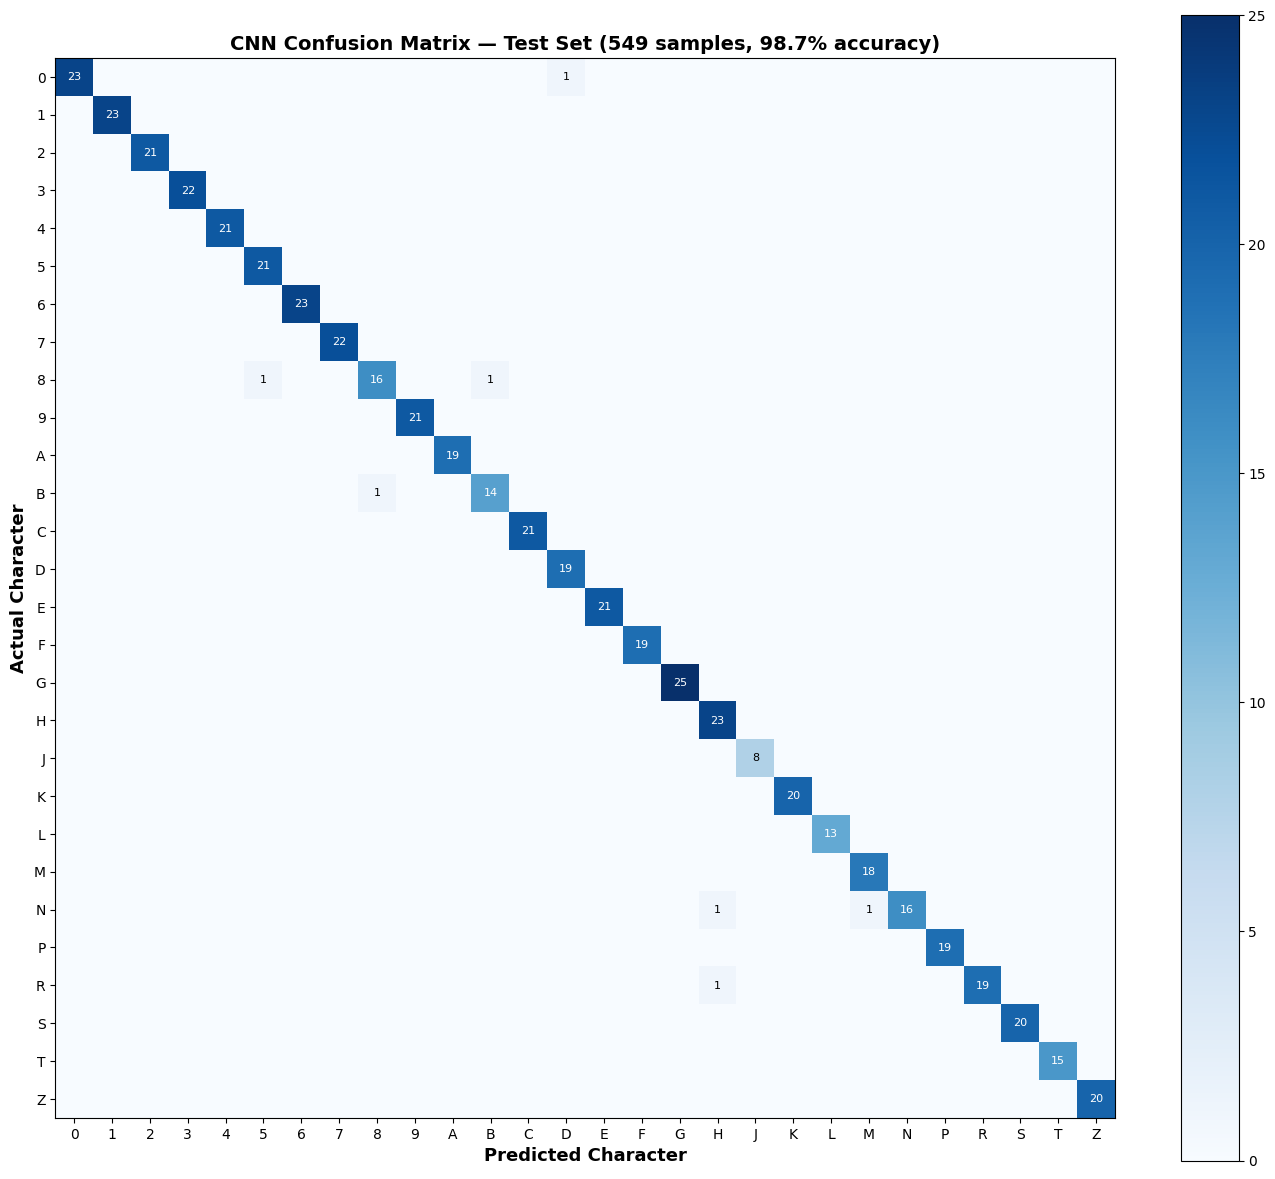

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

labels = [IDX_TO_CHAR[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Predicted Character', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Character', fontsize=13, fontweight='bold')
ax.set_title(f'CNN Confusion Matrix — Test Set ({len(y_true)} samples, {acc*100:.1f}% accuracy)',
             fontsize=14, fontweight='bold')

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm[i, j]
        if val > 0:
            color = 'white' if val > cm.max()*0.5 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

files.download('cnn_confusion_matrix.png')